In [1]:
import pandas as pd
import cyvcf2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Filtering only associative variant sites
This is the SBC10-private variant group: SBC10 carries the alt allele and none of SBC4, SBC11, SBC23 do (the low-TAA accession's private variants, candidate causal sites for TAA loss).

In [24]:
!../docker/run.sh bcftools view -Oz -i 'GT[1]="alt" && GT[0]!="alt" && GT[2]!="alt" && GT[3]!="alt"' ../results/combined/all.annotated.vcf.gz -o ../analysis/data/SBC10.vcf.gz
!../docker/run.sh bcftools index -t ../analysis/data/SBC10.vcf.gz

## Parse VCF into pandas dataframe

In [2]:
ANN_FIELDS = [
    "ann_allele", "ann_effect", "ann_impact", "ann_gene_name", "ann_gene_id",
    "ann_feature_type", "ann_feature_id", "ann_biotype", "ann_rank",
    "ann_hgvs_c", "ann_hgvs_p", "ann_cdna_pos", "ann_cds_pos", "ann_aa_pos",
    "ann_distance", "ann_extra",
]

SIFT_FIELDS = [
    "sift_allele", "sift_transcript", "sift_gene_id", "sift_gene_name",
    "sift_region", "sift_variant_type", "sift_aa_change", "sift_aa_pos",
    "sift_score", "sift_median", "sift_num_seqs", "sift_allele_type",
    "sift_prediction",
]

# Sniffles2 INFO keys -> sniffles_-prefixed column names (same nomenclature as ANN/SIFT)
SNIFFLES_KEY_MAP = {
    "SVTYPE": "sniffles_svtype", "SVLEN": "sniffles_svlen", "END": "sniffles_end",
    "SUPPORT": "sniffles_support", "SUPP_VEC": "sniffles_supp_vec",
    "STRAND": "sniffles_strand", "AF": "sniffles_af",
    "STDEV_POS": "sniffles_stdev_pos", "STDEV_LEN": "sniffles_stdev_len",
    "COVERAGE": "sniffles_coverage", "PRECISE": "sniffles_precise",
    "IMPRECISE": "sniffles_imprecise", "MOSAIC": "sniffles_mosaic",
}
SNIFFLES_FIELDS = list(SNIFFLES_KEY_MAP.values())

# Numeric/flag INFO columns to cast from string -> real dtype after parsing
# (dtypes taken from the VCF header: Type=Integer/Float, Type=Flag). Nullable
# Int64/float tolerate the NaNs left by SNP rows (no sniffles_*) and non-coding
# sites (no sift_*). SUPP_VEC/STRAND/COVERAGE stay strings on purpose ("0100"
# leading zeros, "+-", "48,11,..." Number=. list).
INT_COLS   = ["sniffles_svlen", "sniffles_end", "sniffles_support",
              "sift_aa_pos", "sift_num_seqs", "ann_distance"]
FLOAT_COLS = ["sniffles_af", "sniffles_stdev_pos", "sniffles_stdev_len",
              "sift_score", "sift_median"]
FLAG_COLS  = ["sniffles_precise", "sniffles_imprecise", "sniffles_mosaic"]

# SIFT4G writes DELETERIOUS (score < 0.05) or TOLERATED; NA means non-coding
_SIFT_PRIORITY = {"DELETERIOUS": 0, "TOLERATED": 1}
# impact severity for tiebreaking (HIGH most severe -> lowest rank)
_IMPACT_RANK = {"HIGH": 0, "MODERATE": 1, "LOW": 2, "MODIFIER": 3}


def _parse_info_kv(info_str):
    """Split a raw INFO string into a flat dict.
    'KEY=VALUE' -> {KEY: VALUE} (split on first '=' only), bare flags -> {FLAG: True}."""
    kv = {}
    for token in info_str.split(";"):
        if "=" in token:
            k, v = token.split("=", 1)
            kv[k] = v
        elif token:
            kv[token] = True
    return kv


def parse_info(info_str):
    """Parse a raw VCF INFO string into a structured dict.

    Returns is_sv (True for Sniffles2 SV records), ann_raw / sift_raw (the raw
    ANN= / SIFTINFO= strings, or None), and the Sniffles2 fields renamed with a
    sniffles_ prefix (None when absent / non-SV record). ann_raw / sift_raw are
    consumed by parse_vcf to explode them into ann_* / sift_* columns.
    """
    kv = _parse_info_kv(info_str)
    result = {
        "is_sv":    "SVTYPE" in kv,
        "ann_raw":  kv.get("ANN"),
        "sift_raw": kv.get("SIFTINFO"),
    }
    for vcf_key, col in SNIFFLES_KEY_MAP.items():
        result[col] = kv.get(vcf_key)        # None when absent
    return result


def _parse_ann(raw):
    """Split a SnpEff ANN= string into a list of dicts (one per ANN entry)."""
    records = []
    for entry in raw.split(","):
        parts = entry.split("|")
        parts += [""] * (len(ANN_FIELDS) - len(parts))
        records.append(dict(zip(ANN_FIELDS, parts[:len(ANN_FIELDS)])))
    return records


def _parse_siftinfo(raw):
    """Map (allele, transcript) -> best SIFT record from a SIFTINFO= string.

    SnpEff ann_feature_id and SIFT sift_transcript share the XM_* namespace, so
    they join directly. On duplicate keys, DELETERIOUS beats TOLERATED.
    """
    by_key = {}
    for entry in raw.split(","):
        parts = entry.split("|")
        parts += [""] * (len(SIFT_FIELDS) - len(parts))
        d = dict(zip(SIFT_FIELDS, parts[:len(SIFT_FIELDS)]))
        key = (d["sift_allele"], d["sift_transcript"])
        pred = d.get("sift_prediction", "")
        current = by_key.get(key)
        if current is None or _SIFT_PRIORITY.get(pred, 99) < _SIFT_PRIORITY.get(current.get("sift_prediction", ""), 99):
            by_key[key] = d
    return by_key


def _reduce_annotations(annotations, sift_by_key):
    """Reduce a variant's many ANN entries to ONE per gene (see genomics_scoring.py).

    Deterministic sort (lowest key wins): (1) SIFT match on (allele, transcript),
    (2) impact severity HIGH>MODERATE>LOW>MODIFIER, (3) original ANN order,
    (4) protein_coding over other biotypes. Returns (ann, sift) pairs, one per gene.
    """
    by_gene = {}
    for order, ann in enumerate(annotations):
        key = (ann.get("ann_allele", ""), ann.get("ann_feature_id", ""))
        sort_key = (
            0 if key in sift_by_key else 1,
            _IMPACT_RANK.get(ann.get("ann_impact", ""), 99),
            order,
            0 if ann.get("ann_biotype") == "protein_coding" else 1,
        )
        by_gene.setdefault(ann.get("ann_gene_id", ""), []).append((sort_key, key, ann))

    reduced = []
    for entries in by_gene.values():
        _, key, ann = min(entries, key=lambda t: t[0])
        reduced.append((ann, sift_by_key.get(key, {})))
    return reduced


def _fmt_gt(gt):
    """cyvcf2 genotype list -> VCF-style string: [1, 1, False] -> '1/1',
    [0, 1, True] -> '0|1', missing alleles (-1) -> '.'. Handles haploid too."""
    *alleles, phased = gt
    sep = "|" if phased else "/"
    return sep.join("." if a < 0 else str(a) for a in alleles)


def parse_vcf(vcf_path):
    """Parse an annotated VCF into a tidy DataFrame — one row per (variant, gene).

    Per row: chrom, pos, ref, alt, qual, filter; one GT column per sample;
    is_sv and the sniffles_* fields (None for SNP/indels); the SnpEff ANN entry
    exploded into ann_* columns (one per gene via _reduce_annotations); and the
    matching SIFT4G record exploded into sift_* columns. Records without ANN
    (e.g. the ~0.24% of SVs lacking SnpEff annotation) emit a single row with no
    ann_*/sift_* fields. No scoring is applied.

    INFO-derived columns arrive as strings/None; INT_COLS/FLOAT_COLS/FLAG_COLS
    are cast to nullable Int64 / float64 / bool before returning.
    """
    vcf = cyvcf2.VCF(vcf_path)
    samples = vcf.samples
    rows = []
    for v in vcf:
        base = {
            "chrom":  v.CHROM,
            "pos":    v.POS,
            "ref":    v.REF,
            "alt":    ",".join(v.ALT),
            "qual":   v.QUAL,
            "filter": v.FILTER,
        }
        base.update(zip(samples, map(_fmt_gt, v.genotypes)))

        info = parse_info(";".join(
            k if val is True else f"{k}={val}" for k, val in v.INFO
        ))
        ann_raw = info.pop("ann_raw")
        sift_raw = info.pop("sift_raw")
        base.update(info)                    # is_sv + sniffles_* columns

        if not ann_raw:
            rows.append(base)
            continue

        annotations = _parse_ann(ann_raw)
        sift_by_key = _parse_siftinfo(sift_raw) if sift_raw else {}
        for ann, sift in _reduce_annotations(annotations, sift_by_key):
            rows.append({**base, **ann, **sift})

    vcf.close()

    df = pd.DataFrame(rows)
    for col in INT_COLS:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
    for col in FLOAT_COLS:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    for col in FLAG_COLS:
        if col in df:
            df[col] = df[col].notna()        # flag present -> True, else False
    
    df["sift_score"] = pd.to_numeric(df.get("sift_score"), errors="coerce")
    df["sift_score_c"] = 1 - df["sift_score"]
    return df

IMPACT_BANDS = {
    "MODIFIER": (0.00, 0.25),
    "LOW":      (0.25, 0.50),
    "MODERATE": (0.50, 0.75),
    "HIGH":     (0.75, 1.00),
}

def scoring(df: pd.DataFrame) -> pd.DataFrame:
    lo = df["ann_impact"].map(lambda i: IMPACT_BANDS.get(i, (np.nan, np.nan))[0])
    hi = df["ann_impact"].map(lambda i: IMPACT_BANDS.get(i, (np.nan, np.nan))[1])
    width = hi - lo

    score = lo + 0.5 * width # band midpoint default

    refine = df["ann_impact"].eq("MODERATE") & df["sift_score_c"].notna()
    score = score.mask(refine, lo + df["sift_score_c"] * width) # SIFT within MODERATE only

    df["score"] = score
    return df

def _append_rank(out: pd.DataFrame) -> pd.DataFrame:
    """Insert ``percentile`` and ``rank`` columns immediately right of ``score``.

    ``rank`` is 1 = highest score (dense ranking on ties); ``percentile`` is the
    score's position in [0, 100], higher score -> higher percentile. NaN scores
    (no length/effect match) get NaN rank and percentile. Assumes ``out`` is
    already sorted by score descending.
    """
    percentile = out["score"].rank(ascending=True, pct=True) * 100
    rank = out["score"].rank(ascending=False, method="dense").astype("Int64")
    pos = out.columns.get_loc("score") + 1
    out.insert(pos, "percentile", percentile)
    out.insert(pos + 1, "rank", rank)
    return out

def merge_to_gene_max(df_scored: pd.DataFrame, gene_key: str = "ann_gene_id") -> pd.DataFrame:
    """Collapse variant/transcript rows to one row per gene.

    Maximum / worst-variant approach: each gene's ``score`` is the score of its
    single most damaging variant. Only gene-level columns (GENE_LEVEL_COLS) are
    emitted; variant-level fields are dropped because the output is a per-gene
    product. Rows with no gene id are dropped.
    """
    scored = df_scored[df_scored[gene_key].fillna("").ne("")]
    idx = scored.groupby(gene_key)["score"].idxmax()       # worst variant per gene
    out = scored.loc[idx]
    return _append_rank(out.sort_values("score", ascending=False))

In [3]:
df_variants = parse_vcf("../analysis/data/SBC10.vcf.gz")

In [4]:
df_variants = df_variants[(~df_variants['ann_gene_id'].str.contains("-", regex=False, na=False, case=False)) & ~df_variants['ann_gene_id'].str.contains("&", regex=False, na=False, case=False)]
df_variants

,chrom,pos,ref,alt,qual,filter,SBC4,SBC10,SBC11,SBC23,...,sift_region,sift_variant_type,sift_aa_change,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c
0,NC_012870.2,1619,G,A,54.540001,None,./.,1|0,./.,./.,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
2,NC_012870.2,5784,A,AG,25.700001,None,./.,0/1,./.,./.,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
4,NC_012870.2,5784,A,AGG,25.700001,None,./.,1/0,./.,./.,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
6,NC_012870.2,6934,A,G,31.510000,None,./.,1|0,./.,./.,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
7,NC_012870.2,6934,A,G,31.510000,None,./.,1|0,./.,./.,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
740863,NC_008360.1,263767,N,<INV>,54.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
740864,NC_008360.1,263767,N,<INV>,54.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
740866,NC_008360.1,341568,N,<INV>,59.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN
740867,NC_008360.1,341568,N,<INV>,59.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN


## Variant to gene-level annotation
Converting one-row-per-variant data frame into one-row-per-gene:
1. Score each variant's impact (detected by SnpEff and SIFT)
2. Output worst score (maximum) among variants within one gene

In [5]:
df_variants_scored = scoring(df_variants)
df_variants_scored

,chrom,pos,ref,alt,qual,filter,SBC4,SBC10,SBC11,SBC23,...,sift_variant_type,sift_aa_change,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c,score
0,NC_012870.2,1619,G,A,54.540001,None,./.,1|0,./.,./.,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
2,NC_012870.2,5784,A,AG,25.700001,None,./.,0/1,./.,./.,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
4,NC_012870.2,5784,A,AGG,25.700001,None,./.,1/0,./.,./.,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
6,NC_012870.2,6934,A,G,31.510000,None,./.,1|0,./.,./.,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
7,NC_012870.2,6934,A,G,31.510000,None,./.,1|0,./.,./.,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
740863,NC_008360.1,263767,N,<INV>,54.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
740864,NC_008360.1,263767,N,<INV>,54.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
740866,NC_008360.1,341568,N,<INV>,59.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125
740867,NC_008360.1,341568,N,<INV>,59.000000,None,0/0,0/1,0/0,0/0,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125


In [6]:
df_genes = merge_to_gene_max(df_variants_scored)
df_genes

,chrom,pos,ref,alt,qual,filter,SBC4,SBC10,SBC11,SBC23,...,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c,score,percentile,rank
606138,NC_012877.2,59800110,T,TAG,56.779999,None,./.,1/1,./.,./.,...,<NA>,NaN,NaN,<NA>,NA,NA,NaN,0.875,97.660525,1
441209,NC_012875.2,43649935,ACGCCG,A,29.360001,None,./.,1/1,./.,./.,...,<NA>,NaN,NaN,<NA>,NA,NA,NaN,0.875,97.660525,1
93046,NC_012870.2,80001125,A,AGTGTGTGT,23.070000,None,./.,1/1,./.,./.,...,<NA>,NaN,NaN,<NA>,NA,NA,NaN,0.875,97.660525,1
183865,NC_012871.2,74635683,N,<DEL>,60.000000,None,0/0,1/1,0/0,0/0,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.875,97.660525,1
181544,NC_012871.2,74328071,N,<DEL>,59.000000,None,0/0,0/1,0/0,0/0,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.875,97.660525,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280342,NC_012873.2,12197092,G,A,34.130001,None,./.,1/1,./.,./.,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125,40.772072,101
280144,NC_012873.2,12096481,C,T,40.160000,None,./.,1/1,./.,./.,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125,40.772072,101
279650,NC_012873.2,11584157,C,CA,30.200001,None,./.,1/1,./.,./.,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125,40.772072,101
279648,NC_012873.2,11567393,C,T,36.299999,None,./.,1/1,./.,./.,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.125,40.772072,101


In [7]:
def plot_kdeplot(df: pd.DataFrame, title: str, ax=None, clip=None):
    """KDE of the per-row/per-gene ``score`` column (mirrors the notebook helper).

    The x-axis starts at the LOW band floor so the spike of MODIFIER scores
    (all pinned at the MODIFIER band midpoint) doesn't flatten the rest of the
    distribution. Ticks sit at the midpoint of each visible impact band and are
    labeled with that band's range (MODIFIER has no tick since its range falls
    entirely outside the clipped view).
    """
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(8, 5))

    x_min = IMPACT_BANDS["LOW"][0]
    x_max = clip[1] if clip is not None else df["score"].max()
    effective_clip = (x_min, x_max)

    sns.kdeplot(
        data=df,
        x="score",
        fill=True,
        clip=effective_clip,
        cut=0,
        bw_adjust=1.0,
        ax=ax,
    )

    ax.set_xlim(effective_clip)

    band_colors = {"MODIFIER": "0.6", "LOW": "tab:blue", "MODERATE": "tab:orange", "HIGH": "tab:red"}
    ticks, ticklabels = [], []
    for band, (lo, hi) in IMPACT_BANDS.items():
        vis_lo, vis_hi = max(lo, x_min), min(hi, x_max)
        if vis_hi > vis_lo:
            ax.axvspan(vis_lo, vis_hi, color=band_colors[band], alpha=0.08, zorder=0)
        mid = (lo + hi) / 2
        if mid >= x_min:
            ticks.append(mid)
            ticklabels.append(f"{band}\n[{lo:.2f}, {hi:.2f})")

    ax.set_xticks(ticks)
    ax.set_xticklabels(ticklabels)

    ax.set_title(f"Scores distribution on {title}")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")

    if own_fig:
        fig.tight_layout()
    return ax

def raw_variant_plotting(df: pd.DataFrame, sample: str, out_path: str) -> str:
    """Render the KDE of the raw, variant-level ``score`` column and save it.

    Unlike plotting_summary (which plots the gene-collapsed MAX/SUM tables), this
    plots every (variant, gene) row's severity score straight from scoring() --
    the input distribution before any gene-level aggregation or length
    normalization. Saves the figure to ``out_path`` and returns that path.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_kdeplot(df, "variant", ax=ax)
    fig.suptitle(f"{sample}: variant-level score distribution", y=1.02)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return out_path

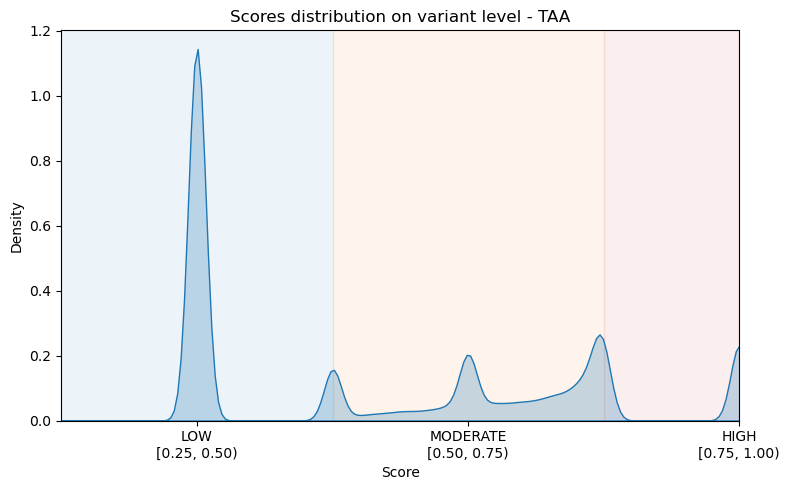

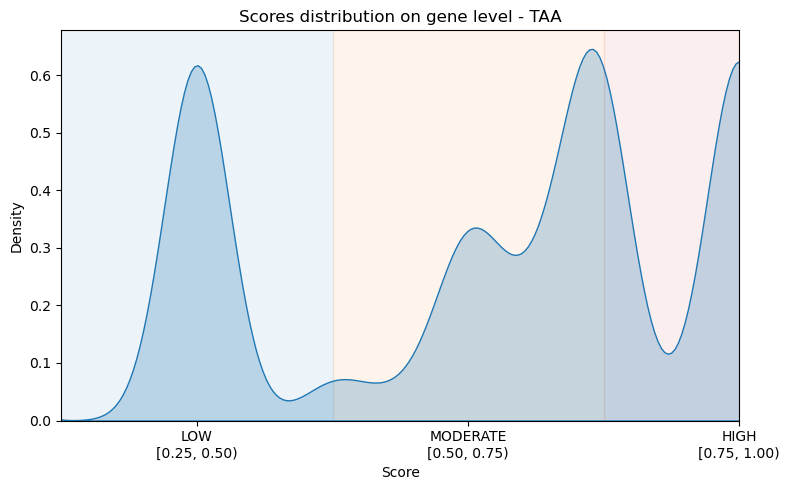

In [8]:
plot_kdeplot(df_variants_scored, "variant level - TAA")
plt.show()

plot_kdeplot(df_genes, "gene level - TAA")
plt.show()

In [9]:
df_genes[(df_genes["ann_impact"] == "HIGH") | (df_genes["ann_impact"] == "MODERATE")].describe()

,pos,qual,sniffles_svlen,sniffles_end,sniffles_support,sniffles_af,sniffles_stdev_pos,sniffles_stdev_len,ann_distance,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_score_c,score,percentile,rank
count,3.032000e+03,3032.000000,255.0,255.0,439.0,0.0,439.000000,439.000000,6.0,1786.0,1664.000000,1664.000000,1664.0,1664.000000,3032.000000,3032.000000,3032.0
mean,3.622709e+07,38.521336,-5928.12549,35408983.894118,8.920273,NaN,15.487569,12.181847,1390.5,241.033595,0.201653,3.098107,159.859976,0.798347,0.750096,93.088745,18.440633
std,2.662458e+07,14.156485,15186.418639,26144991.834793,7.542908,NaN,71.605201,58.881506,3260.901271,252.080137,0.282968,0.519132,147.630726,0.282968,0.106112,3.906510,25.7296
min,1.240400e+04,20.000000,-87500.0,184053.0,1.0,NaN,0.000000,0.000000,2.0,1.0,0.000000,2.130000,1.0,0.000000,0.500000,86.373586,1.0
25%,7.135802e+06,28.340000,-8572.5,8004745.0,3.0,NaN,0.000000,0.000000,25.75,75.0,0.010000,2.690000,30.0,0.710000,0.675000,89.638818,1.0
50%,4.650624e+07,32.700001,-3042.0,42914975.0,6.0,NaN,0.000000,0.000000,71.5,172.0,0.060000,2.960000,94.0,0.940000,0.747500,93.291682,3.0
75%,5.976624e+07,47.882501,-102.0,59637987.0,12.0,NaN,0.000000,0.000000,124.0,329.0,0.290000,3.360000,308.25,0.990000,0.875000,97.660525,32.0
max,8.087721e+07,110.000000,65671.0,80879616.0,39.0,NaN,542.351013,565.815002,8046.0,3062.0,1.000000,4.320000,400.0,1.000000,0.875000,97.660525,99.0


# DMR analysis

In [10]:
# DMR_annotated.tsv schema (one row per DMR x overlapping feature x gene):
#   chr, start, end, diff.Methy, direction (= "hyper_<accession>"),
#   sample_a, sample_b, feature (promoter|exon|CDS|intron|intergenic), gene_label
DMR_PATH = Path("../results/DMR/DMR_annotated.tsv")

df_dmr = pd.read_csv(DMR_PATH, sep="\t")
print(f"{len(df_dmr):,} DMR-feature rows | features: {sorted(df_dmr['feature'].unique())}")

# --- Candidate genes: promoter HYPOMETHYLATED in the low-TAA accession SBC10 ---
# SBC10 is the lone low-TAA accession. A promoter LESS methylated in SBC10 than
# in a high-TAA accession is de-repressed in SBC10 / silenced in the high-TAA
# ones -- the expression contrast that could underlie the low-vs-high TAA
# split. So candidates are genes whose promoter is hypomethylated in SBC10.
#
# Direction encoding: `direction` names the HYPER accession ("hyper_<acc>").
# Hypomethylated in SBC10  <=>  the contrast involves SBC10 AND the hyper side
# is the OTHER accession, i.e. direction != "hyper_SBC10".
SBC10 = "SBC10"

promoter_dmr = df_dmr[
    (df_dmr["feature"] == "promoter")
    & df_dmr["gene_label"].notna()
    & (df_dmr["gene_label"].astype(str).str.strip() != "")
].copy()

involves_sbc10 = (promoter_dmr["sample_a"] == SBC10) | (promoter_dmr["sample_b"] == SBC10)
hypo_in_sbc10  = involves_sbc10 & (promoter_dmr["direction"] != f"hyper_{SBC10}")
sbc10_hypo = promoter_dmr[hypo_in_sbc10].copy()
sbc10_hypo["abs_diff"] = sbc10_hypo["diff.Methy"].abs()

# one row per gene: its strongest SBC10-hypomethylated promoter DMR
promoter_candidates = (
    sbc10_hypo
    .sort_values("abs_diff", ascending=False)
    .drop_duplicates(subset="gene_label")
    .loc[:, ["gene_label", "diff.Methy", "abs_diff", "direction",
             "sample_a", "sample_b", "chr", "start", "end"]]
    .reset_index(drop=True)
)
print(f"{int(hypo_in_sbc10.sum()):,} promoter DMRs hypomethylated in {SBC10} -> "
      f"{len(promoter_candidates):,} candidate genes")
promoter_candidates.head(20)

152,253 DMR-feature rows | features: ['CDS', 'exon', 'intergenic', 'promoter']
3,091 promoter DMRs hypomethylated in SBC10 -> 2,617 candidate genes


,gene_label,diff.Methy,abs_diff,direction,sample_a,sample_b,chr,start,end
0,LOC8058048,-0.748799,0.748799,hyper_SBC4,SBC10,SBC4,NC_012872.2,58259104,58262211
1,LOC110436238,-0.692811,0.692811,hyper_SBC23,SBC10,SBC23,NC_012875.2,542007,542225
2,LOC110433864,-0.646674,0.646674,hyper_SBC23,SBC10,SBC23,NC_012872.2,58071613,58071928
3,LOC110432936,-0.595732,0.595732,hyper_SBC4,SBC10,SBC4,NC_012871.2,75831277,75831716
4,LOC8083747,-0.590963,0.590963,hyper_SBC23,SBC10,SBC23,NC_012878.2,41580761,41581267
5,LOC8063333,-0.560185,0.560185,hyper_SBC23,SBC10,SBC23,NC_012871.2,66387757,66389692
6,LOC8064193,-0.534160,0.534160,hyper_SBC23,SBC10,SBC23,NC_012878.2,53816849,53817492
7,LOC8068993,-0.527613,0.527613,hyper_SBC23,SBC10,SBC23,NC_012878.2,55936766,55937814
8,LOC8061075,-0.527613,0.527613,hyper_SBC23,SBC10,SBC23,NC_012878.2,55936766,55937814
9,LOC8068380,-0.526789,0.526789,hyper_SBC23,SBC10,SBC23,NC_012879.2,1606812,1607682


## Promoter hypomethylated in SBC10 across the high-vs-low TAA contrasts

In [11]:
# --- Refinement: hypomethylated in SBC10 in >=1 low-vs-high-TAA contrast ----
# Candidate genes have a promoter hypomethylated in SBC10 in at least one
# SBC10-vs-high-TAA contrast (mirrors the variant analysis's union-of-groups
# logic, which also doesn't require the signal to hold across all three
# high-TAA accessions -- just SBC10 absent and at least one high-TAA sample
# present).
HIGH_TAA = ["SBC4", "SBC11", "SBC23"]

low_vs_high = promoter_dmr[
    ((promoter_dmr["sample_a"] == SBC10) & promoter_dmr["sample_b"].isin(HIGH_TAA))
    | ((promoter_dmr["sample_b"] == SBC10) & promoter_dmr["sample_a"].isin(HIGH_TAA))
].copy()
low_vs_high["hypo_in_low"] = low_vs_high["direction"] != f"hyper_{SBC10}"

phenotype_candidates = (
    low_vs_high[low_vs_high["hypo_in_low"]]
    .groupby("gene_label")
    .agg(n_hypo_low=("hypo_in_low", "sum"), mean_diff=("diff.Methy", "mean"))
    .sort_values("mean_diff", key=lambda s: s.abs(), ascending=False)
    .reset_index()
)
print(f"{len(phenotype_candidates)} genes with a promoter hypomethylated in {SBC10} "
      f"in at least one low-vs-high-TAA contrast")
phenotype_candidates.head(20)

2617 genes with a promoter hypomethylated in SBC10 in at least one low-vs-high-TAA contrast


,gene_label,n_hypo_low,mean_diff
0,LOC8058048,1,-0.748799
1,LOC110436238,1,-0.692811
2,LOC110433864,1,-0.646674
3,LOC8083747,1,-0.590963
4,LOC8064193,1,-0.534160
5,LOC8061075,1,-0.527613
6,LOC8068993,1,-0.527613
7,LOC8068380,1,-0.526789
8,LOC8070710,1,-0.521013
9,LOC8056817,1,-0.517006


In [12]:
phenotype_candidates

,gene_label,n_hypo_low,mean_diff
0,LOC8058048,1,-0.748799
1,LOC110436238,1,-0.692811
2,LOC110433864,1,-0.646674
3,LOC8083747,1,-0.590963
4,LOC8064193,1,-0.534160
...,...,...,...
2612,LOC110431795,1,-0.027013
2613,LOC8054790,1,-0.010283
2614,LOC110434467,1,-0.008849
2615,LOC8056081,1,-0.008849


In [13]:
df_genes[df_genes["percentile"] > 50]

,chrom,pos,ref,alt,qual,filter,SBC4,SBC10,SBC11,SBC23,...,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c,score,percentile,rank
606138,NC_012877.2,59800110,T,TAG,56.779999,None,./.,1/1,./.,./.,...,<NA>,NaN,NaN,<NA>,NA,NA,NaN,0.875,97.660525,1
441209,NC_012875.2,43649935,ACGCCG,A,29.360001,None,./.,1/1,./.,./.,...,<NA>,NaN,NaN,<NA>,NA,NA,NaN,0.875,97.660525,1
93046,NC_012870.2,80001125,A,AGTGTGTGT,23.070000,None,./.,1/1,./.,./.,...,<NA>,NaN,NaN,<NA>,NA,NA,NaN,0.875,97.660525,1
183865,NC_012871.2,74635683,N,<DEL>,60.000000,None,0/0,1/1,0/0,0/0,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.875,97.660525,1
181544,NC_012871.2,74328071,N,<DEL>,59.000000,None,0/0,0/1,0/0,0/0,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.875,97.660525,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
560311,NC_012877.2,19709636,C,T,34.160000,None,./.,1/1,./.,./.,...,487,1.00,3.23,326,novel,TOLERATED,0.00,0.375,83.858537,100
100609,NC_012871.2,4591564,C,T,41.910000,None,./.,1/1,./.,./.,...,365,1.00,4.04,22,novel,TOLERATED,0.00,0.375,83.858537,100
456613,NC_012875.2,52087523,C,T,31.879999,None,./.,1/1,./.,./.,...,246,0.49,2.84,396,novel,TOLERATED,0.51,0.375,83.858537,100
309155,NC_012873.2,49454322,TA,T,23.230000,None,./.,1/1,./.,./.,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,0.375,83.858537,100


In [14]:
print(len(df_genes[df_genes["ann_impact"] == "HIGH"]))
print(len(df_genes[df_genes["ann_impact"] == "MODERATE"]))


1027
2005


# Refining the causative candidate genes list
Aconitate isomerase is hypothesized to be:
- An isomerase-family gene (candidates: `analysis/data/sorghum_isomerase.txt`, every isomerase-family gene annotated in the sorghum genome)
- Co-expressed with genes upregulated by phytochrome, reflecting the hypothesis that aconitate isomerase activity is light-regulated

## Phytochrome-upregulated module genes
Literature-curated Arabidopsis phytochrome-upregulated genes, mapped to their
Sorghum orthologs via BioMart (`analysis/data/sorghum_biomart_light_induced.txt`):

| AGI | Name | Sorghum ortholog (EGI) |
|-----|------|-------------------------|
| AT5G08740 | alternative NAD(P)H-ubiquinone oxidoreductase C1, chloroplastic/mitochondrial | LOC8080027 |
| AT1G01060 | protein CCA1 | LOC8080836 |
| AT5G52640 | heat shock protein 82 | LOC8057342 |
| AT2G16850 | -- | no Sorghum ortholog |

In [15]:
# Phytochrome module: map the BioMart Ath->Sbi orthologs to EGI, same SORBI->EGI
# lookup as the dPCD module in positive_control.ipynb (NCBI gene_info's LocusTag
# holds the SORBI_3xxxGxxxxxx stable ID, Symbol holds the LOC<GeneID> id).
light = pd.read_csv("../analysis/data/sorghum_biomart_light_induced.txt", sep="\t")

SORBI_COL = "Sorghum bicolor gene stable ID  EGI Sorghum bicolor"
light["sorbi_id"] = light[SORBI_COL].str.split().str[0]  # drop the manually appended "  LOC..." annotation

gene_info = pd.read_csv(
    "../resources/NCBI_FTP/gene_info_4558",
    sep="\t",
    usecols=["GeneID", "Symbol", "LocusTag", "description"],
    dtype=str,
)
sorbi_to_egi = gene_info.set_index("LocusTag")["Symbol"].to_dict()
light["egi"] = light["sorbi_id"].map(sorbi_to_egi)

n_sorbi = light["sorbi_id"].notna().sum()
n_mapped = light["egi"].notna().sum()
unmapped = sorted(light.loc[light["sorbi_id"].notna() & light["egi"].isna(), "sorbi_id"].unique())
print(f"{n_mapped}/{n_sorbi} SORBI IDs mapped to an EGI"
      + (f" ({len(unmapped)} unmapped: {unmapped})" if unmapped else ""))

MODULE_GENES = sorted(light["egi"].dropna().str.removeprefix("LOC").unique().tolist())
print(f"{len(MODULE_GENES)}-gene phytochrome-upregulated module: {MODULE_GENES}")

isomerase_genes = [l.strip() for l in open("../analysis/data/sorghum_isomerase.txt") if l.strip()]
print(f"{len(isomerase_genes)} isomerase-family candidates")

10/10 SORBI IDs mapped to an EGI
3-gene phytochrome-upregulated module: ['8057342', '8080027', '8080836']
461 isomerase-family candidates


# Gene Co-expression

ATTED-II Sbi-r.c1-0 (v25-12, subagging z-transformed Mutual Rank): one file per
gene under `ATTED_ZD`, each a two-column `<partner_EGI>` / `<coex_score>` table.
The z-transform standardizes Mutual Rank onto a comparable scale across bait
genes, so the per-bait scores are directly comparable and averageable across
the module without re-deriving Mutual Rank on top.

`coex_matrix`: isomerase candidates (rows) x module genes (columns), z-scored
co-expression read straight from each module gene's own ATTED-II neighborhood
file.

In [16]:
# ATTED_ZD = Path("/mnt/hdd/daffa/Sbi-r.c1-0/Sbi-r.v25-12.G21627-S807.combat_pca.subagging.z.d")
ATTED_ZD = Path("/Users/daffa/workspace/infobio/Sbi-r.c1-0/Sbi-r.v25-12.G21627-S807.combat_pca.subagging.z.d")


def load_neighborhood(egi):
    """partner_EGI -> z-scored coex value, from egi's own ATTED-II neighborhood file."""
    neigh = {}
    with open(ATTED_ZD / egi) as f:
        for line in f:
            partner, score = line.rstrip("\n").split("\t")
            neigh[partner] = float(score)
    return neigh

module_neigh = {b: load_neighborhood(b) for b in MODULE_GENES}

coex_matrix = pd.DataFrame({
    b: pd.Series({c: neigh[c] for c in isomerase_genes if c in neigh})
    for b, neigh in module_neigh.items()
}).reindex(isomerase_genes)

print(f"{coex_matrix.notna().any(axis=1).sum()}/{len(coex_matrix)} isomerase candidates "
      f"profiled by ATTED-II (of those, {coex_matrix.notna().all(axis=1).sum()} have all "
      f"{len(MODULE_GENES)} module genes)")
coex_matrix

404/461 isomerase candidates profiled by ATTED-II (of those, 404 have all 3 module genes)


,8057342,8080027,8080836
8054237,0.4841,-0.9107,-0.0025
8054265,0.1759,-0.7160,1.2463
8054392,-0.6512,2.0897,-1.6729
8054550,-0.2782,-0.6512,-0.0349
8054630,-0.2619,1.0193,-1.0566
...,...,...,...
110436943,0.3706,0.7274,0.6625
110437006,8.0416,-0.5863,-1.5918
110437176,0.7598,1.2950,0.1597
110437264,NaN,NaN,NaN


In [ ]:
coex_matrix["8080027"].max()

4.3602

In [17]:
from scipy.stats import beta

# Robust Rank Aggregation (Kolde et al. 2012): treat each module gene (column)
# as a ranked list of the isomerase candidates by co-expression, then aggregate
# those 3 lists into one ranking. A candidate that sits near the top across all
# 3 module genes gets a small rho -- it is the most consistently co-expressed
# with the phytochrome module, not just strongly tied to one bait.
def rra_score(norm_ranks: np.ndarray) -> float:
    """RRA rho for one item: min over order statistics of the Beta CDF,
    Bonferroni-corrected by the number of lists and capped at 1.
    norm_ranks are the item's normalized ranks (in (0, 1], smaller = better)."""
    r = np.sort(np.asarray(norm_ranks, dtype=float))
    n = len(r)
    k = np.arange(1, n + 1)                          # order-statistic indices
    return min(beta.cdf(r, k, n - k + 1).min() * n, 1.0)

# RRA needs an actual ranked list per voter, so it only covers the candidates
# ATTED-II profiled against the module (all-or-nothing here: every profiled
# candidate has all 3 module genes, see coex_matrix above).
assayed = coex_matrix.dropna(how="all")
n_iso = assayed.shape[0]
norm_ranks = assayed.rank(axis=0, ascending=False, method="average") / n_iso

iso_rra = (
    norm_ranks.apply(rra_score, axis=1).rename("rra_score")
    .sort_values()
    .to_frame()
    .assign(rank=lambda d: np.arange(1, len(d) + 1),
            mean_coex=assayed.mean(axis=1), stdev_coex=assayed.std(axis=1))
)
iso_rra.index.name = "EGI"
iso_rra = iso_rra.join(gene_info.set_index("GeneID")["description"])
iso_rra

,rra_score,rank,mean_coex,stdev_coex,description
EGI,,,,,
110433915,0.007154,1,1.538233,1.591762,DEAD-box ATP-dependent RNA helicase 15
8155424,0.011316,2,1.716633,1.109591,inositol-3-phosphate synthase
110432775,0.015489,3,2.338333,2.701602,inositol-3-phosphate synthase
110433588,0.018065,4,1.381500,0.559997,DEAD-box ATP-dependent RNA helicase 40-like
8072909,0.022222,5,2.587000,5.471046,70 kDa peptidyl-prolyl isomerase
...,...,...,...,...,...
8075341,1.000000,400,-0.099767,0.844708,kinesin-like protein KIN-13A
8075459,1.000000,401,-0.148433,0.467502,DNA replication licensing factor MCM4
8057814,1.000000,402,-1.316100,2.528309,peptidyl-prolyl cis-trans isomerase CYP18-2
